# HW02 Part 3: Analyzing Wikipedia Data Directly from S3

This notebook loads the hourly Wikipedia event data directly from my S3 bucket, combines all 24 hourly files into one DataFrame, and creates visualizations of hourly event counts.

In [1]:
import boto3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Locate the hourly Parquet files in S3

List the hourly Parquet files stored in the `wikipedia-hourly` prefix of my S3 bucket.

In [2]:
bucket_name = "dsan6000-jt1573"
prefix = "wikipedia-hourly/"

s3 = boto3.client("s3")

In [3]:
response = s3.list_objects_v2(
    Bucket=bucket_name,
    Prefix=prefix
)

In [4]:
parquet_keys = []

for obj in response.get("Contents", []):
    key = obj["Key"]

    if key.endswith(".parquet"):
        parquet_keys.append(key)

parquet_keys = sorted(parquet_keys)

print(f"Found {len(parquet_keys)} Parquet files in S3.")
parquet_keys[:5]

Found 24 Parquet files in S3.


['wikipedia-hourly/20260901_040000.parquet',
 'wikipedia-hourly/20260901_050000.parquet',
 'wikipedia-hourly/20260901_060000.parquet',
 'wikipedia-hourly/20260901_070000.parquet',
 'wikipedia-hourly/20260901_080000.parquet']

## Load the hourly data directly from S3

Construct S3 URIs for each hourly Parquet file and load the data directly from S3 using Pandas.

In [5]:
s3_uris = []

for key in parquet_keys:
    uri = f"s3://{bucket_name}/{key}"
    s3_uris.append(uri)

s3_uris[:5]

['s3://dsan6000-jt1573/wikipedia-hourly/20260901_040000.parquet',
 's3://dsan6000-jt1573/wikipedia-hourly/20260901_050000.parquet',
 's3://dsan6000-jt1573/wikipedia-hourly/20260901_060000.parquet',
 's3://dsan6000-jt1573/wikipedia-hourly/20260901_070000.parquet',
 's3://dsan6000-jt1573/wikipedia-hourly/20260901_080000.parquet']

In [10]:
hour_df = pd.read_parquet(s3_uris[0])


In [11]:
hour_df.shape

(4458, 29)

In [12]:
hour_df.columns.tolist()

['datetime',
 '$schema',
 'meta',
 'id',
 'type',
 'namespace',
 'title',
 'title_url',
 'comment',
 'timestamp',
 'user',
 'bot',
 'notify_url',
 'minor',
 'length',
 'revision',
 'server_url',
 'server_name',
 'server_script_path',
 'wiki',
 'parsedcomment',
 'log_id',
 'log_type',
 'log_action',
 'log_params',
 'log_action_comment',
 'patrolled',
 'file_ts',
 'file_ts_str']

In [13]:
hour_df.head()

,datetime,$schema,meta,id,type,namespace,title,title_url,comment,timestamp,...,wiki,parsedcomment,log_id,log_type,log_action,log_params,log_action_comment,patrolled,file_ts,file_ts_str
0,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Jake_O%...,2.063884e+09,edit,0,Jake O'Donnell,https://en.wikipedia.org/wiki/Jake_O%27Donnell,Fix dash,1788235202,...,enwiki,Fix dash,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
1,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Beverid...,2.063884e+09,edit,0,Beveridge Award,https://en.wikipedia.org/wiki/Beveridge_Award,Add source,1788235202,...,enwiki,Add source,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
2,2026-09-01 04:00:01,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1920_Un...,2.063884e+09,edit,0,1920 United States presidential election in Wa...,https://en.wikipedia.org/wiki/1920_United_Stat...,/* Counties that flipped from Democratic to Re...,1788235201,...,enwiki,"<span class=""autocomment""><a href=""/wiki/1920_...",NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
3,2026-09-01 04:00:02,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/1987_Ae...,2.063884e+09,edit,0,1987 Aegean crisis,https://en.wikipedia.org/wiki/1987_Aegean_crisis,added a bit of context,1788235202,...,enwiki,added a bit of context,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000
4,2026-09-01 04:00:03,/mediawiki/recentchange/1.0.0,{'uri': 'https://en.wikipedia.org/wiki/Marvin_...,2.063884e+09,edit,0,Marvin Schwäbe,https://en.wikipedia.org/wiki/Marvin_Schw%C3%A4be,NaN,1788235203,...,enwiki,NaN,NaN,NaN,NaN,NaN,NaN,None,2026-09-01 04:00:00,20260901_040000


## Combine all 24 hourly files

Load each hourly Parquet file directly from S3 and combine the resulting DataFrames into one full-day DataFrame.

In [14]:
hourly_dfs = []

for uri in s3_uris:
    df = pd.read_parquet(uri)
    hourly_dfs.append(df)

all_events = pd.concat(hourly_dfs, ignore_index=True)

all_events.shape

(119708, 29)

## Prepare the datetime column for hourly analysis

Convert the event timestamps to datetime values and create an hourly time variable for grouping events.

In [15]:
all_events[["datetime", "type"]].head()

,datetime,type
0,2026-09-01 04:00:02,edit
1,2026-09-01 04:00:02,edit
2,2026-09-01 04:00:01,edit
3,2026-09-01 04:00:02,edit
4,2026-09-01 04:00:03,edit


In [16]:
all_events["datetime"] = pd.to_datetime(
    all_events["datetime"],
    utc=True
)

In [17]:
all_events["hour"] = all_events["datetime"].dt.floor("h")

## Total hourly event counts

Count the total number of Wikipedia events in each hour of the day.

In [18]:
hourly_counts = (
    all_events
    .groupby("hour")
    .size()
    .reset_index(name="event_count")
)

hourly_counts

,hour,event_count
0,2026-09-01 04:00:00+00:00,4458
1,2026-09-01 05:00:00+00:00,3769
2,2026-09-01 06:00:00+00:00,3981
3,2026-09-01 07:00:00+00:00,3186
4,2026-09-01 08:00:00+00:00,3519
5,2026-09-01 09:00:00+00:00,3316
6,2026-09-01 10:00:00+00:00,3654
7,2026-09-01 11:00:00+00:00,4056
8,2026-09-01 12:00:00+00:00,4599
9,2026-09-01 13:00:00+00:00,6200


## Plot total events per hour

Visualize the total number of Wikipedia events recorded during each hour.

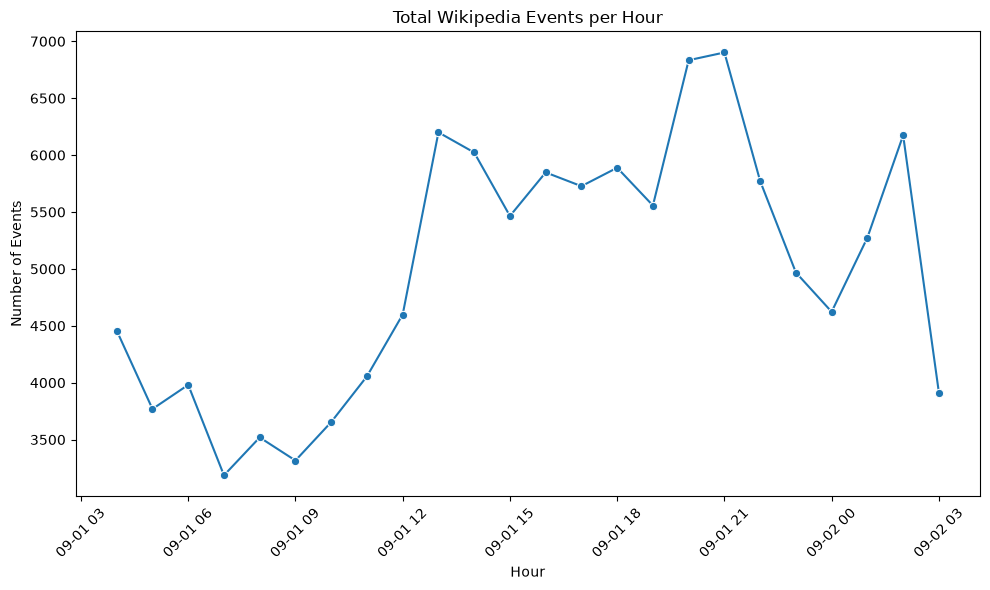

In [19]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=hourly_counts,
    x="hour",
    y="event_count",
    marker="o"
)

plt.title("Total Wikipedia Events per Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("images/hourly-events.png")
plt.savefig("images/hourly-events.svg")

plt.show()

## Hourly event counts by type

Count Wikipedia events for each hour separately by event type.

In [20]:
hourly_type_counts = (
    all_events
    .groupby(["hour", "type"])
    .size()
    .reset_index(name="event_count")
)

hourly_type_counts.head()

,hour,type,event_count
0,2026-09-01 04:00:00+00:00,edit,3959
1,2026-09-01 04:00:00+00:00,log,440
2,2026-09-01 04:00:00+00:00,new,59
3,2026-09-01 05:00:00+00:00,edit,3429
4,2026-09-01 05:00:00+00:00,log,199


## Plot hourly events by type

Visualize how the number of events changes by hour for each event type.

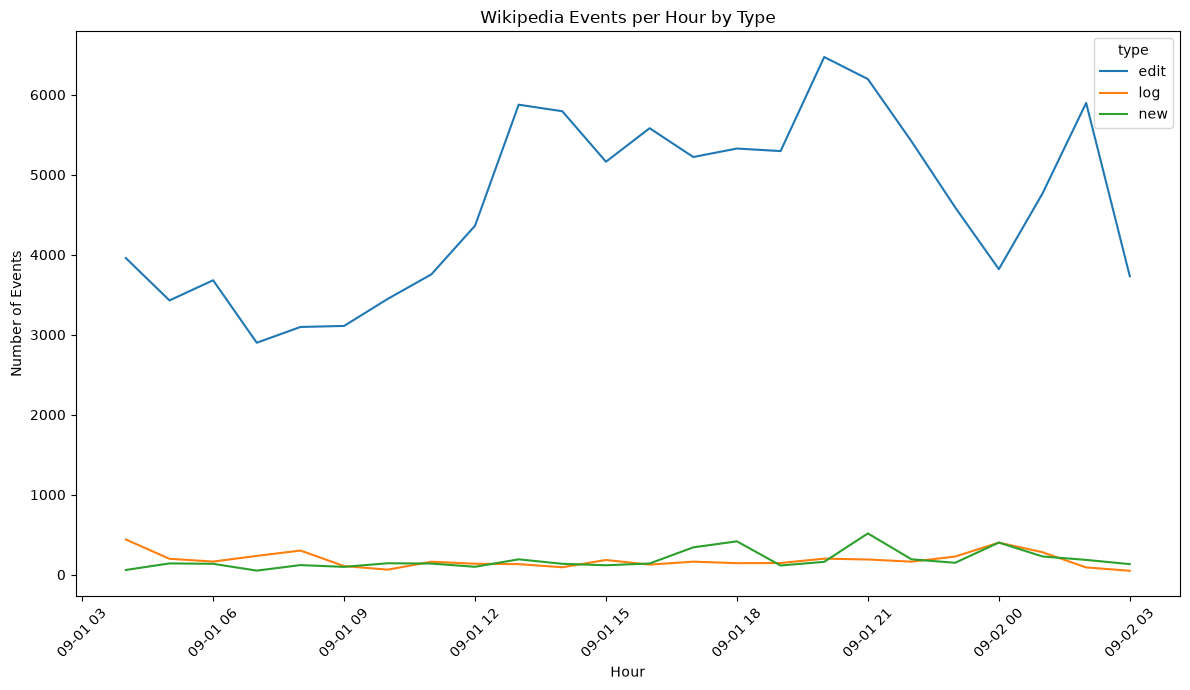

In [21]:
plt.figure(figsize=(12, 7))

sns.lineplot(
    data=hourly_type_counts,
    x="hour",
    y="event_count",
    hue="type"
)

plt.title("Wikipedia Events per Hour by Type")
plt.xlabel("Hour")
plt.ylabel("Number of Events")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("images/events-by-type.png")
plt.savefig("images/events-by-type.svg")

plt.show()